# Mealpy Timetabling

Revenue-maximizing railway timetabling solved with several metaheuristics
from the `mealpy` library, on top of the robin simulator. The discrete part
(which services are scheduled) is obtained with the conflict-avoiding heuristic,
so mealpy only optimizes the real-valued departure times.


## 0. Load Libraries


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

from robin.supply.generator.entities import SupplyGenerator
from robin.supply.entities import Supply

from craft import RevenueSimulator, Solution
from craft.mealpy import MealpyTimetabling
from mealpy import FloatVar, GA, DE, PSO, SCA

## 1. Generate Supply


In [2]:
supply_config_path = Path('../configs/supply_generator/supply_data.yaml')
generator_config_path = Path('../configs/supply_generator/config.yaml')
generator_save_path = Path('../data/results/supply_mealpy.yaml')

Path('../data/results').mkdir(parents=True, exist_ok=True)

generator = SupplyGenerator.from_yaml(
    path_config_supply=supply_config_path,
    path_config_generator=generator_config_path,
)

generator.generate(
    n_services=25,
    output_path=generator_save_path,
    seed=42,
    progress_bar=True,
    without_conflicts=False,
)

print(f'Generated {len(generator.services)} services')

Generating services all: 100%|██████████| 25/25 [00:00<00:00, 461.81service/s]

Generated 25 services


## 2. Load Supply and Generate Revenue Behavior


In [3]:
supply = Supply.from_yaml(path=str(generator_save_path))
print(f'Loaded {len(supply.services)} services')

revenue_simulator = RevenueSimulator(supply=supply)
revenue_behavior = revenue_simulator.simulate_revenue(alpha=2/3)

print(f'Revenue behavior computed for {len(revenue_behavior)} services')

Loaded 25 services
Revenue behavior computed for 25 services


## 3. Initialize Timetabling Problem


In [4]:
timetabling = MealpyTimetabling(
    requested_services=supply.services,
    revenue_behavior=revenue_behavior,
    safe_headway=10,
    max_stop_time=10,
)

print(f'Problem initialized with {timetabling.n_services} services')
print(f'Real variables: {len(timetabling.boundaries.real)}')

Problem initialized with 25 services
Real variables: 81


## 4. Define MEALPY Problem


In [5]:
bounds = [FloatVar(lb=lb, ub=ub) for lb, ub in timetabling.boundaries.real]

problem = {
    'obj_func': timetabling.objective_function,
    'bounds': bounds,
    'minmax': 'max',
    'verbose': False,
}

print(f'Number of real variables: {len(bounds)}')

Number of real variables: 81


## 5. Run GA Optimization


In [6]:
model = GA.BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01)

print('Starting GA optimization...')
model.solve(problem, seed=42)

print(f'Best fitness: {model.g_best.target.fitness}')

2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01)


Starting GA optimization...


2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 544.5849615223184, Global best: 544.5849615223184, Runtime: 0.02399 seconds
2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 515.563576030139, Global best: 544.5849615223184, Runtime: 0.02431 seconds
2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 515.997383596238, Global best: 544.5849615223184, Runtime: 0.02471 seconds
2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 516.1182537951979, Global best: 544.5849615223184, Runtime: 0.02521 seconds
2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 516.2731620375205, Global best: 544.5849615223184, Runtime: 0.02464 seconds
2026/06/18 04:12:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 6, 

Best fitness: 587.796369394982


## 6. Results


In [7]:
best_position = model.g_best.solution
best_fitness = model.g_best.target.fitness

schedule = timetabling.get_heuristic_schedule()

print(f'Best fitness: {best_fitness}')
print(f'Scheduled services: {sum(schedule)}/{len(schedule)}')

Best fitness: 587.796369394982
Scheduled services: 23/25


## 7. Update Supply with Solution


In [8]:
solution = Solution(real=best_position, discrete=schedule)
updated_services = timetabling.update_supply(str(generator_save_path), solution)

print(f'Updated supply contains {len(updated_services)} services')

Updated supply contains 23 services


## 8. Convergence


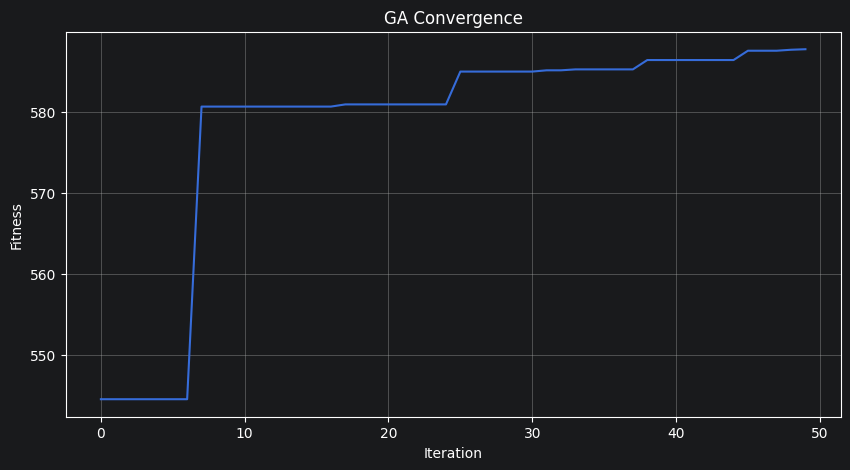

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot([data.target.fitness for data in model.history.list_global_best])
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('GA Convergence')
plt.grid(True)
plt.show()

## 9. Compare Algorithms


In [10]:
algorithms = {
    'GA': GA.BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01),
    'DE': DE.OriginalDE(epoch=50, pop_size=20, wf=0.5, cr=0.9),
    'PSO': PSO.OriginalPSO(epoch=50, pop_size=20, c1=1.5, c2=1.5, w=0.7),
    'SCA': SCA.OriginalSCA(epoch=50, pop_size=20),
}

results = {}
for name, algo in algorithms.items():
    print(f'Running {name}...')
    algo.solve(problem, seed=42)
    results[name] = algo.g_best.target.fitness
    print(f'{name} best fitness: {results[name]:.2f}')

print('\n=== Results Summary ===')
for name, fitness in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'{name}: {fitness:.2f}')

2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=50, pop_size=20, pc=0.9, pm=0.01)
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 544.5849615223184, Global best: 544.5849615223184, Runtime: 0.02368 seconds


Running GA...


2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 515.563576030139, Global best: 544.5849615223184, Runtime: 0.02539 seconds
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 515.997383596238, Global best: 544.5849615223184, Runtime: 0.02726 seconds
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 516.1182537951979, Global best: 544.5849615223184, Runtime: 0.02339 seconds
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 516.2731620375205, Global best: 544.5849615223184, Runtime: 0.02309 seconds
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 6, Current best: 516.5962745786069, Global best: 544.5849615223184, Runtime: 0.02440 seconds
2026/06/18 04:12:48 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 7, 

GA best fitness: 587.80
Running DE...


2026/06/18 04:12:49 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 15, Current best: 662.8580729548258, Global best: 662.8580729548258, Runtime: 0.01283 seconds
2026/06/18 04:12:49 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 16, Current best: 662.8580729548258, Global best: 662.8580729548258, Runtime: 0.01271 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 17, Current best: 662.8580729548258, Global best: 662.8580729548258, Runtime: 0.01377 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 18, Current best: 662.8580729548258, Global best: 662.8580729548258, Runtime: 0.01272 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.evolutionary_based.DE.OriginalDE: >>>Problem: P, Epoch: 19, Current best: 662.8580729548258, Global best: 662.8580729548258, Runtime: 0.01265 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.evolutionary_based.DE.Origin

DE best fitness: 791.97
Running PSO...


2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 14, Current best: 534.9495938471274, Global best: 534.9495938471274, Runtime: 0.01168 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 15, Current best: 534.9495938471274, Global best: 534.9495938471274, Runtime: 0.01187 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 16, Current best: 534.9495938471274, Global best: 534.9495938471274, Runtime: 0.01233 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 17, Current best: 534.9495938471274, Global best: 534.9495938471274, Runtime: 0.01193 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 18, Current best: 534.9495938471274, Global best: 534.9495938471274, Runtime: 0.01169 seconds
2026/06/18 04:12:50 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 19

PSO best fitness: 536.47
Running SCA...


2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 10, Current best: 523.2826975411272, Global best: 523.2826975411272, Runtime: 0.01823 seconds
2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 11, Current best: 531.6350103165303, Global best: 531.6350103165303, Runtime: 0.01817 seconds
2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 12, Current best: 531.6350103165303, Global best: 531.6350103165303, Runtime: 0.01760 seconds
2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 13, Current best: 531.6350103165303, Global best: 531.6350103165303, Runtime: 0.01865 seconds
2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 14, Current best: 531.6350103165303, Global best: 531.6350103165303, Runtime: 0.01815 seconds
2026/06/18 04:12:51 PM, INFO, mealpy.math_based.SCA.OriginalSCA: >>>Problem: P, Epoch: 15, Curr

SCA best fitness: 533.66

=== Results Summary ===
DE: 791.97
GA: 587.80
PSO: 536.47
SCA: 533.66
